<a href="https://colab.research.google.com/github/jhamidi1/Data201-Spring/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("Population_Health_Measures__Age-Adjusted_Mortality_Rates_20260514.csv")

df.head()

,Unique ID,3-Year Period,Cause of Death,Race,Hispanic or Latino Origin,Gender,"Age-Adjusted Rate per 100,000 Population",Lower 95% Confidence Interval,Upper 95% Confidence Interval
0,A2010201200000,2010-2012,All causes of mortality,Total,Total,Total,517.3,509.6,525.1
1,A2010201200001,2010-2012,All causes of mortality,Total,Total,Male,609.3,596.2,622.5
2,A2010201200002,2010-2012,All causes of mortality,Total,Total,Female,450.2,440.8,459.6
3,A2010201200010,2010-2012,All causes of mortality,Total,Not Hispanic,Total,531.8,523.6,540.0
4,A2010201200011,2010-2012,All causes of mortality,Total,Not Hispanic,Male,623.4,609.5,637.2


# 1. Introduction


This project uses a Montgomery County, Maryland public health dataset that has age adjusted mortality rates across different demographic groups and causes of death. The dataset includes variables likd race, gender, Hispanic or Latino origin, cause of death, and mortality rates per 100,000 population. The goal of this project is to predict mortality rates using Decision Tree, Random Forest, and Gradient Boosting regression models.
This topic is important because mortality rates can help reveal public health patterns and disparities in different populations, one limitation of the dataset is that it does not include all factors that may affect mortality rates. So things like income, healthcare access, or environmental conditions are left out. The dataset also contains some missing values that required cleaning before analysis.

Dataset Source: https://data.montgomerycountymd.gov/Health-and-Human-Services/Population-Health-Measures-Age-Adjusted-Mortality-/j55i-sqj8/about_data


# 2. Dataset and Preparation


The dataset contains 12,150 rows and 9 columns which are related to mortality rates in Montgomery County, MD. Then I removed rows with missing target values. The target variable used for prediction was the age-adjusted mortality rate per 100,000 population.
Many categorical variables, like race, gender, cause of death, Hispanic or Latino origin, and 3 year period, were converted into numerical form using one hot encoding with pd.get_dummies(). Rows that had missing mortality rate values were removed during data cleaning.

In [48]:
df.describe()

,"Age-Adjusted Rate per 100,000 Population",Lower 95% Confidence Interval,Upper 95% Confidence Interval
count,9240.000000,9244.000000,9240.000000
mean,15.573474,13.926893,45.046071
std,69.455843,65.582681,82.084391
min,0.000000,0.000000,0.100000
25%,0.000000,0.000000,1.300000
50%,0.000000,0.000000,16.300000
75%,3.000000,1.800000,58.100000
max,827.600000,774.200000,880.900000


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unique ID                                 12150 non-null  object 
 1   3-Year Period                             12150 non-null  object 
 2   Cause of Death                            12150 non-null  object 
 3   Race                                      12150 non-null  object 
 4   Hispanic or Latino  Origin                12150 non-null  object 
 5   Gender                                    12150 non-null  object 
 6   Age-Adjusted Rate per 100,000 Population  9240 non-null   float64
 7   Lower 95% Confidence Interval             9244 non-null   float64
 8   Upper 95% Confidence Interval             9240 non-null   float64
dtypes: float64(3), object(6)
memory usage: 854.4+ KB


In [50]:
df.shape

(12150, 9)

In [51]:
df.columns

Index(['Unique ID', '3-Year Period', 'Cause of Death', 'Race',
       'Hispanic or Latino  Origin', 'Gender',
       'Age-Adjusted Rate per 100,000 Population',
       'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval'],
      dtype='object')

In [52]:
df.isnull().sum()

,0
Unique ID,0
3-Year Period,0
Cause of Death,0
Race,0
Hispanic or Latino Origin,0
Gender,0
"Age-Adjusted Rate per 100,000 Population",2910
Lower 95% Confidence Interval,2906
Upper 95% Confidence Interval,2910


In [53]:
df.columns = [
    'unique_id',
    'period',
    'cause_of_death',
    'race',
    'hispanic_origin',
    'gender',
    'mortality_rate',
    'lower_ci',
    'upper_ci'
]


In [54]:
df = df.dropna(subset=['mortality_rate'])


In [55]:
X = df[['period',
        'cause_of_death',
        'race',
        'hispanic_origin',
        'gender']]
y = df['mortality_rate']

In [56]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,period_2007-2009,period_2008-2010,period_2009-2011,period_2010-2012,cause_of_death_Acute bronchitis and bronchiolitis,cause_of_death_Acute poliomyelitis,cause_of_death_All causes of mortality,cause_of_death_All other diseases (residual),cause_of_death_Alzheimer's disease,cause_of_death_Anemias,...,cause_of_death_Viral hepatitis,cause_of_death_Whooping cough,race_Asian/Pacific Islander,race_Black,race_Total,race_White,hispanic_origin_Not Hispanic,hispanic_origin_Total,gender_Male,gender_Total
0,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,True
1,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,True,True,False
2,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,True
4,False,False,False,True,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,True,False


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7392, 65)
(1848, 65)


| Variable        | Description                                        |
| --------------- | -------------------------------------------------- |
| period          | 3-year mortality reporting period                  |
| cause_of_death  | category of cause of death                         |
| race            | racial demographic group                           |
| hispanic_origin | Hispanic or Latino origin category                 |
| gender          | gender category                                    |
| mortality_rate  | age-adjusted mortality rate per 100,000 population |


# 3. Exploratory Data Analysis


**Visualization 1:
Mortality Rate by Cause of Death**

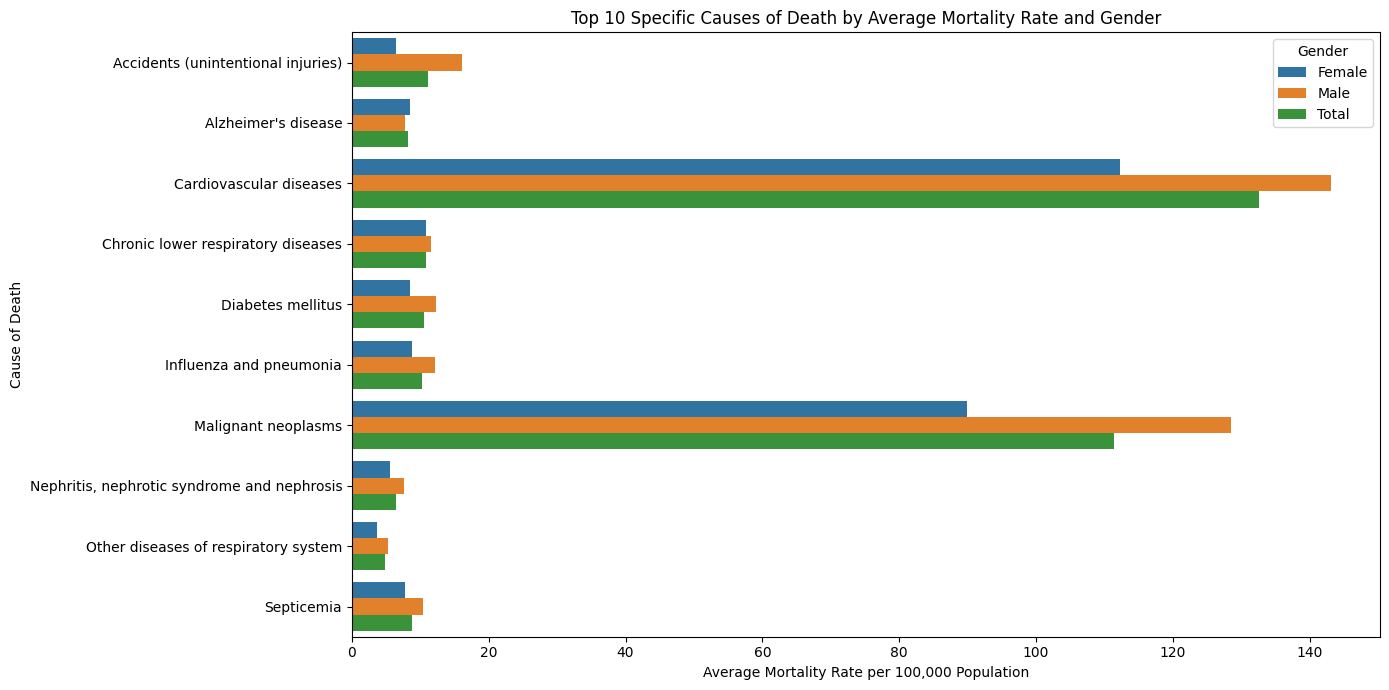

In [58]:
df_filtered = df[
    ~df['cause_of_death'].isin([
        'All causes of mortality',
        'All other diseases (residual)'
    ])
]
# Top 10 specific causes of death by average mortality rate
top_causes = (
    df_filtered.groupby('cause_of_death')['mortality_rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top_df = df_filtered[df_filtered['cause_of_death'].isin(top_causes)]

cause_gender = (
    top_df.groupby(['cause_of_death', 'gender'])['mortality_rate']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=cause_gender,
    x='mortality_rate',
    y='cause_of_death',
    hue='gender')
plt.title('Top 10 Specific Causes of Death by Average Mortality Rate and Gender')
plt.xlabel('Average Mortality Rate per 100,000 Population')
plt.ylabel('Cause of Death')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

This visualization shows the top 10 specific causes of death by average mortality rate and compares mortality rates across gender groups. Cardiovascular diseases and malignant neoplasms had the highest mortality rates overall, making them some of the most significant contributors to mortality. In many categories, males had higher mortality rates than females, suggesting that gender may influence mortality outcomes. The differences across causes of death and demographic groups indicate that variables such as cause of death and gender may be important predictors in the machine learning models.

**Visualization 2 — Mortality Rate by Race**

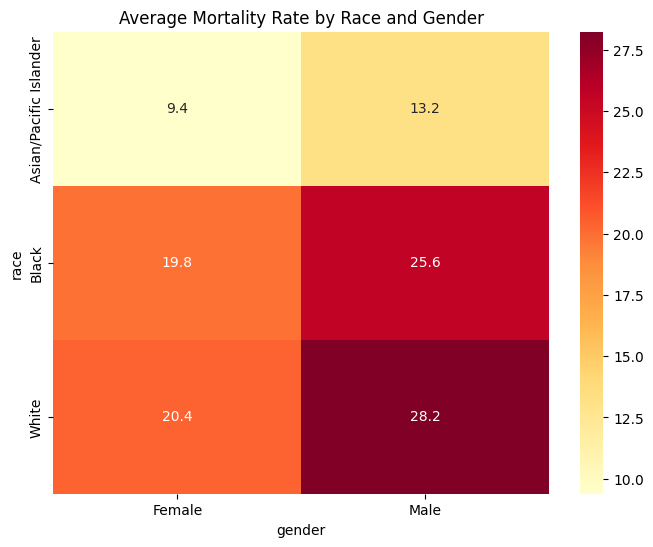

In [59]:
heat_df = df[
    (df['race'] != 'Total') &
    (df['race'] != 'American Indian/Alaska Native') &
    (df['gender'] != 'Total')
]

pivot_table = heat_df.pivot_table(
    values='mortality_rate',
    index='race',
    columns='gender',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(
    pivot_table,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f'
)
plt.title('Average Mortality Rate by Race and Gender')
plt.show()

The heatmap above provides the comparison of the mean mortality rates among various races and genders. Areas with darker color indicate higher mortality rates while the areas with light colors indicate lower mortality rates. There is an obvious trend from the above graph where males have higher mean mortality rates compared to females among all races. The white and black races have higher mortality rates compared to Asian/Pacific Islander races.

# 4. Decision Tree Analysis (Core Section)


**1. Train First Decision Tree**

In [60]:
tree_depth3 = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)
tree_depth3.fit(X_train, y_train)

y_pred_depth3 = tree_depth3.predict(X_test)
mse_depth3 = mean_squared_error(y_test, y_pred_depth3)
r2_depth3 = r2_score(y_test, y_pred_depth3)

print("Depth 3 MSE:", mse_depth3)
print("Depth 3 R²:", r2_depth3)

Depth 3 MSE: 540.598941965597
Depth 3 R²: 0.9020157597142576


**2. Train Second Tree**

In [61]:
tree_depth8 = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)
tree_depth8.fit(X_train, y_train)

y_pred_depth8 = tree_depth8.predict(X_test)
mse_depth8 = mean_squared_error(y_test, y_pred_depth8)
r2_depth8 = r2_score(y_test, y_pred_depth8)

print("Depth 8 MSE:", mse_depth8)
print("Depth 8 R²:", r2_depth8)

Depth 8 MSE: 36.62278007838279
Depth 8 R²: 0.9933620749051327


**3. Visualize the Tree**

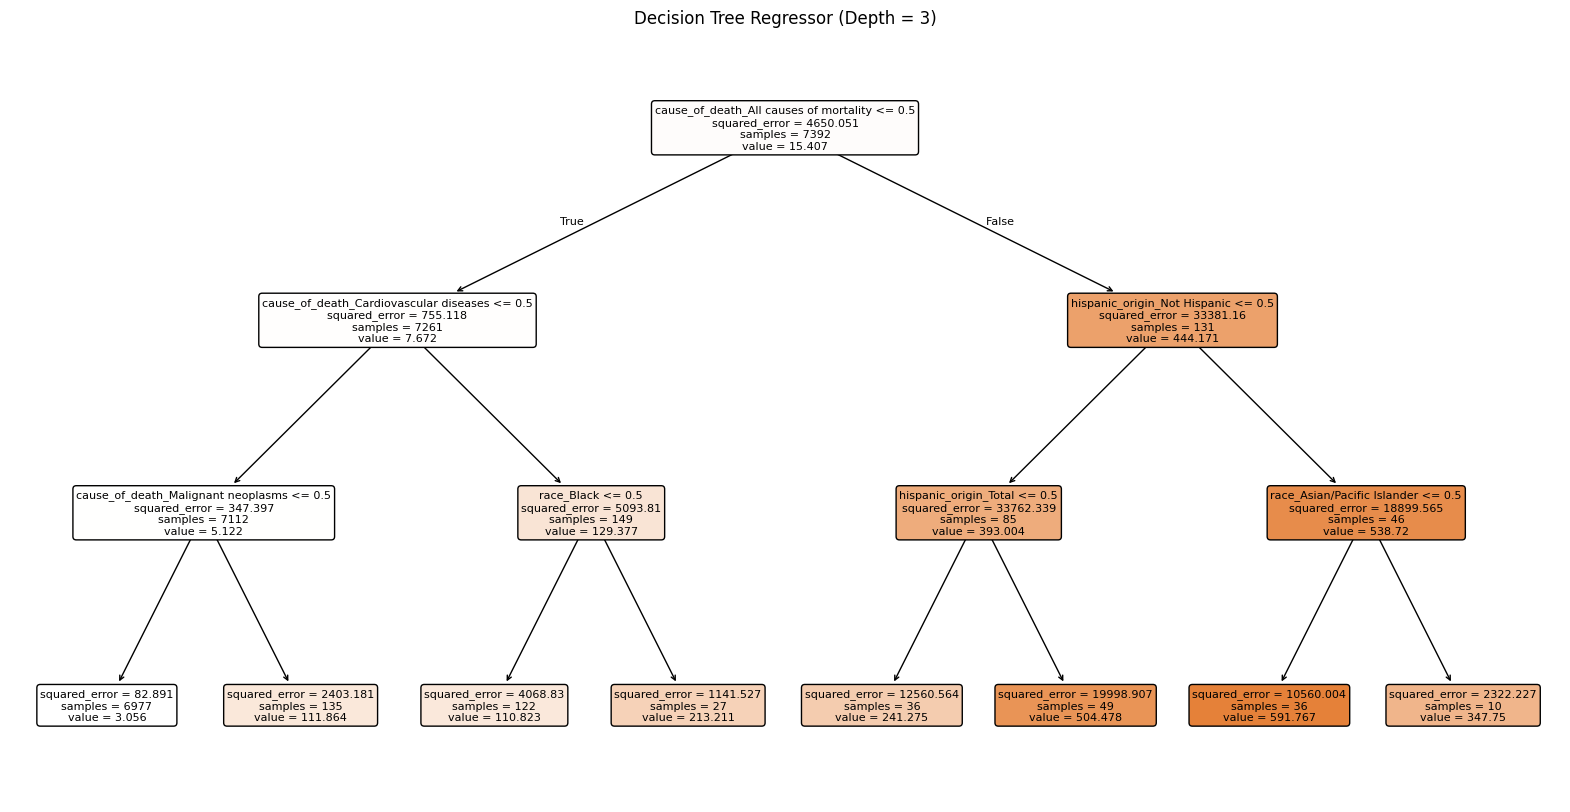

In [62]:
plt.figure(figsize=(20,10))
plot_tree(
    tree_depth3,
    filled=True,
    feature_names=X.columns,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Regressor (Depth = 3)")
plt.show()

The root node of the decision tree was based on whether the cause of death category was “All causes of mortality.” This was the first and most important split in the tree, suggesting that cause of death had the strongest influence on mortality rate predictions.

**4. Comparison Table**

In [63]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree Depth 3', 'Decision Tree Depth 8'],
    'MSE': [mse_depth3, mse_depth8],
    'R²': [r2_depth3, r2_depth8]
})

comparison

,Model,MSE,R²
0,Decision Tree Depth 3,540.598942,0.902016
1,Decision Tree Depth 8,36.622780,0.993362


The deeper decision tree (depth 8) performed better than tree (depth 3). The depth 8 model produced a lower MSE and a higher R² value, showing more accurate predictions. But, deeper trees are more likely to overfit because they create more complex decision rules that may fit the training data too closely.

One important split in the decision tree involved cardiovascular diseases. The model separated observations based on whether cardiovascular disease was present, leading to noticeably different predicted mortality rates, this shows that cardiovascular disease was an important factor in how the model generated predictions.

One prediction path showed that if the cause of death was related to cardiovascular diseases and the individual belonged to the Black racial category, the model predicted a much higher mortality rate. This demonstrates how the decision tree combines multiple demographic and health related conditions to make predictions.

While the tree for depth 3 was simpler and easier to interpret, the depth 8 tree performed better on describing better. While deeper trees tend to have greater accuracy, they are also at an increased risk of overfitting as well. This was done through a comparison of various tree depths.

# 5. Ensemble Models


**1. Random Forest Model**

In [64]:
rf_model = RandomForestRegressor(
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R²:", rf_r2)

Random Forest MSE: 54.26405526190481
Random Forest R²: 0.9901645715207492


**2. Gradient Boosting Model**

In [65]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting MSE: 141.23769606826465
Gradient Boosting R²: 0.974400489393044


**3. Final Comparison Table**

In [66]:
all_models = pd.DataFrame({
    'Model': [
        'Decision Tree Depth 3',
        'Decision Tree Depth 8',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MSE': [
        mse_depth3,
        mse_depth8,
        rf_mse,
        gb_mse
    ],
    'R²': [
        r2_depth3,
        r2_depth8,
        rf_r2,
        gb_r2
    ]
})

all_models

,Model,MSE,R²
0,Decision Tree Depth 3,540.598942,0.902016
1,Decision Tree Depth 8,36.622780,0.993362
2,Random Forest,54.264055,0.990165
3,Gradient Boosting,141.237696,0.974400


The more complicated decision tree (depth 8) turned out to give the most favorable results for the regression model because it gave the minimum MSE value and maximum R². The second model with a good result was the Random Forest model. Gradient Boosting was a good choice but not as accurate as the others.

Did performance improve? Yes, model performance improved significantly when comparing the depth 8 decision tree to the shallower depth 3 tree. The ensemble models also achieved strong predictive performance, particularly the Random Forest model.

Which model generalized better? The Random Forest and Gradient Boosting models are generally expected to generalize better because they combine predictions from multiple trees, reducing the risk of overfitting. However, in this dataset, the depth 8 decision tree achieved the best test performance overall.

Which model was easier to explain? The single decision tree was the easiest model to explain because its decision-making process could be visualized directly through the tree diagram. In contrast, ensemble models combine many trees together, making them more difficult to interpret.

# 6. Model Evaluation


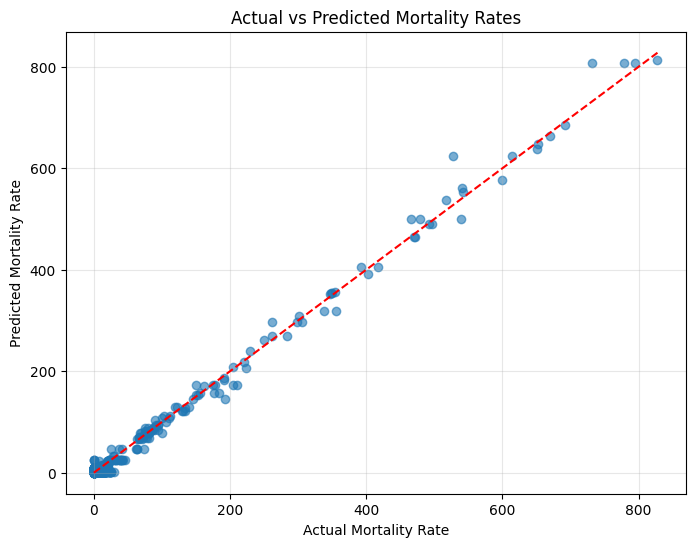

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_depth8, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel('Actual Mortality Rate')
plt.ylabel('Predicted Mortality Rate')

plt.title('Actual vs Predicted Mortality Rates')

plt.grid(alpha=0.3)

plt.show()

The Actual versus Predicted chart shows how well the predicted value correlates with the real value, in terms of mortality rates based on the data in the test set. Almost all points lie near the red line that shows reference values, meaning that the predictions made by the depth 8 decision tree were quite accurate. Such good results show that the model was able to identify the patterns present in the data and make correct predictions.

# 7. Feature Importance


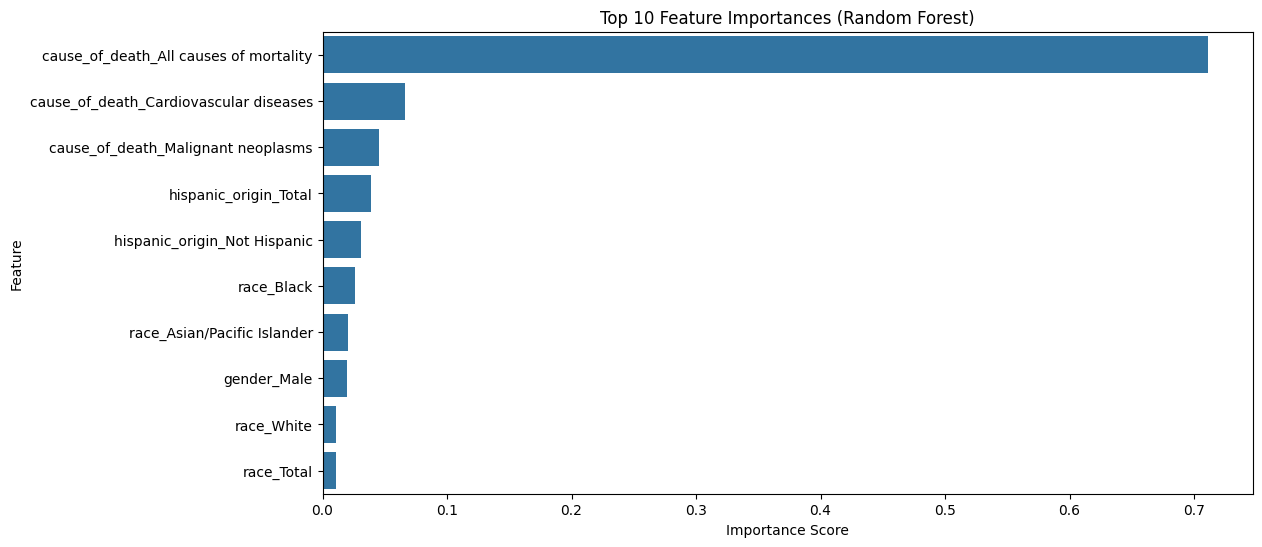

In [68]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# top 10 features
top_features = feature_importance.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

In [69]:
feature_importance.head(3)

,Feature,Importance
6,cause_of_death_All causes of mortality,0.711398
12,cause_of_death_Cardiovascular diseases,0.066055
33,cause_of_death_Malignant neoplasms,0.045276


In terms of feature importance from the random forest, the factors that had the highest influence on mortality prediction were determined. Although “All causes of mortality” was shown to be the most important factor, this is simply a general factor that summarizes all types of deaths, and therefore cannot be used for further interpretation of the results. In addition to the factor described above, the most influential factors included cardiovascular diseases and malignant neoplasms. The demographic characteristics, including the race, sex, and ethnicity of patients, also played a role in predicting mortality rates. It should be noted that feature importance does not confirm causality.

# 8. Final Reflection: The Model Battle


Out of all the models that were used, the decision tree regressor that had a depth of eight gave the best results. It provided us with the least amount of MSE, and the greatest R² value, which means that it was able to predict values most accurately. Although the random forest and gradient boosting methods did a decent job, the deeper decision tree proved to be better.

From all of the models, the decision tree would have been the simplest one to explain because it is a visual object that allows us to trace its splits and prediction paths and, therefore understand how it generates its predictions depending on certain variables.

However, if I were to use either of the models in the real world, I would definitely prefer to use the Random Forest model despite the fact that the decision tree of depth 8 performed better on this data set. The reason behind this is the greater reliability of the Random Forest model compared to any other model due to its capability to incorporate predictions from various trees instead of just one.